In [2]:
!pip install rasterio
!pip install opencv-python

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import numpy as np
import rasterio
import cv2
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

from tensorflow.keras import layers, models

In [5]:
dataset_path="/content/drive/MyDrive/Satellite_Images_Samples"

files=os.listdir(dataset_path)

b02=sorted([f for f in files if "B02_10m" in f])
b03=sorted([f for f in files if "B03_10m" in f])
b04=sorted([f for f in files if "B04_10m" in f])

scene_list=[]

for i in range(len(b02)):
    scene_list.append((
        os.path.join(dataset_path,b02[i]),
        os.path.join(dataset_path,b03[i]),
        os.path.join(dataset_path,b04[i])
    ))

print("Scenes found:",len(scene_list))

Scenes found: 20


In [6]:
def load_scene(b02_path,b03_path,b04_path):

    with rasterio.open(b02_path) as src:
        b02 = src.read(1).astype(np.float32)

    with rasterio.open(b03_path) as src:
        b03 = src.read(1).astype(np.float32)

    with rasterio.open(b04_path) as src:
        b04 = src.read(1).astype(np.float32)

    # normalize reflectance values
    b02 = b02 / 10000.0
    b03 = b03 / 10000.0
    b04 = b04 / 10000.0

    rgb = np.dstack((b04,b03,b02))
    rgb = np.clip(rgb,0,1)

    # resize large Sentinel tile
    rgb = cv2.resize(rgb,(2048,2048),interpolation=cv2.INTER_AREA)

    return rgb

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

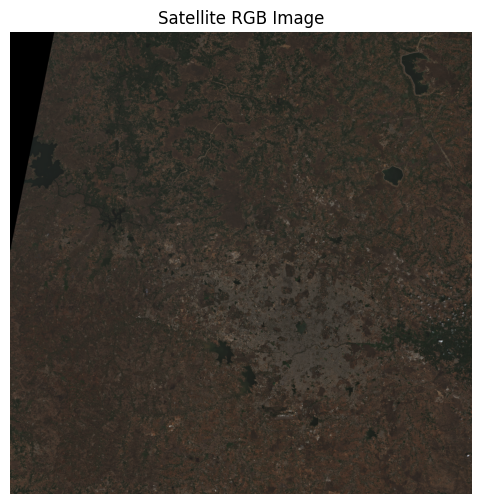

In [7]:
img = load_scene(*scene_list[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Satellite RGB Image")
plt.axis("off")

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

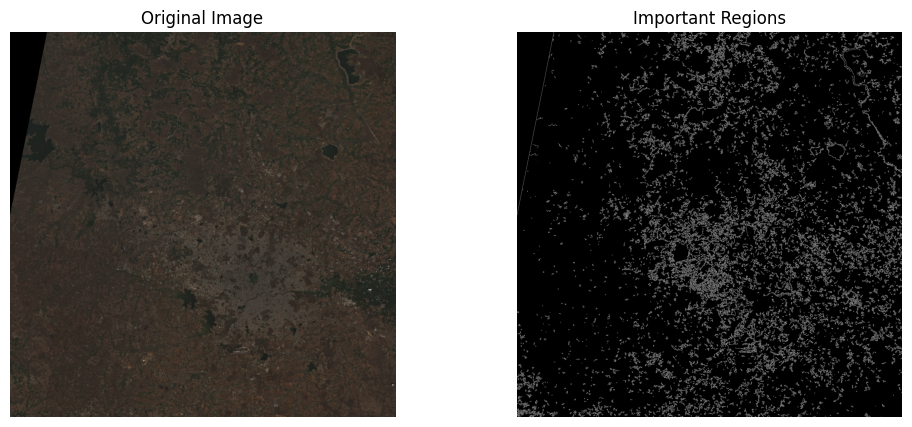

In [8]:
gray=cv2.cvtColor((img*255).astype(np.uint8),cv2.COLOR_RGB2GRAY)

edges=cv2.Canny(gray,50,150)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray")
plt.title("Important Regions")
plt.axis("off")

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

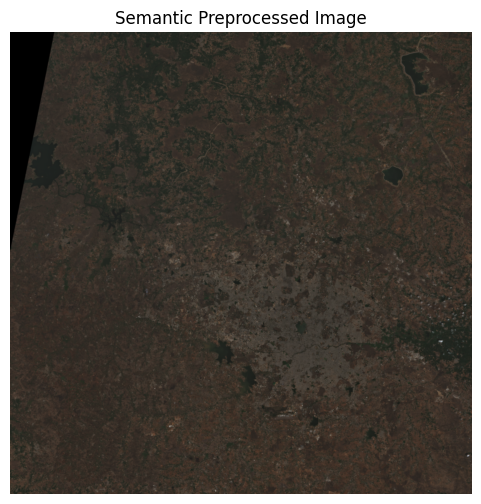

In [9]:
mask=edges>np.mean(edges)

blur=cv2.GaussianBlur(img,(5,5),0)

semantic=img.copy()

mask3=np.stack([mask]*3,axis=-1)

semantic[~mask3]=blur[~mask3]

plt.figure(figsize=(6,6))
plt.imshow(semantic)
plt.title("Semantic Preprocessed Image")
plt.axis("off")

In [10]:
patch_size = 128

In [11]:
def extract_patches(img):

    patches=[]
    h,w,_=img.shape

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):

            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    return np.array(patches)

In [12]:
patches=[]

for scene in scene_list:

    img=load_scene(*scene)

    gray=cv2.cvtColor((img*255).astype(np.uint8),cv2.COLOR_RGB2GRAY)
    edges=cv2.Canny(gray,50,150)

    mask=edges>np.mean(edges)

    blur=cv2.GaussianBlur(img,(5,5),0)

    semantic=img.copy()

    mask3=np.stack([mask]*3,axis=-1)

    semantic[~mask3]=blur[~mask3]

    p=extract_patches(semantic)

    patches.extend(p)

patches=np.array(patches)

print("Total patches:",patches.shape)

Total patches: (5120, 128, 128, 3)


In [13]:
np.random.shuffle(patches)

train_patches=patches[:2500]
test_patches=patches[2500:3000]

print("Train:",train_patches.shape)
print("Test:",test_patches.shape)

Train: (2500, 128, 128, 3)
Test: (500, 128, 128, 3)


In [14]:
input_img=layers.Input(shape=(128,128,3))

x=layers.Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x=layers.MaxPooling2D((2,2))(x)

x=layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
x=layers.MaxPooling2D((2,2))(x)

x=layers.Conv2D(32,(3,3),activation='relu',padding='same')(x)

encoded=layers.MaxPooling2D((2,2))(x)

x=layers.Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
x=layers.UpSampling2D((2,2))(x)

x=layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
x=layers.UpSampling2D((2,2))(x)

x=layers.Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=layers.UpSampling2D((2,2))(x)

decoded=layers.Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

autoencoder=models.Model(input_img,decoded)

autoencoder.compile(optimizer='adam',loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,931 (331.76 KB)

 Trainable params: 84,931 (331.76 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history=autoencoder.fit(
train_patches,
train_patches,
epochs=35,
batch_size=16,
validation_split=0.2
)

Epoch 1/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - loss: 0.0294 - val_loss: 0.0022
Epoch 2/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - loss: 0.0017 - val_loss: 0.0011
Epoch 3/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - loss: 9.0951e-04 - val_loss: 7.2743e-04
Epoch 4/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 7.5827e-04 - val_loss: 6.3927e-04
Epoch 5/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - loss: 5.9188e-04 - val_loss: 6.4133e-04
Epoch 6/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - loss: 5.1848e-04 - val_loss: 5.0794e-04
Epoch 7/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 4.5905e-04 - val_loss: 5.5854e-04
Epoch 8/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - loss: 7.1687e-04 - val_loss: 4.8840e-04
Epoch 9/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - loss: 3.8176e-04 - val_loss: 4.1937e-04
Epoch 10/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 5.2126e-04 - val_loss: 4.4855e-04
Epoch 11/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - loss: 6.3

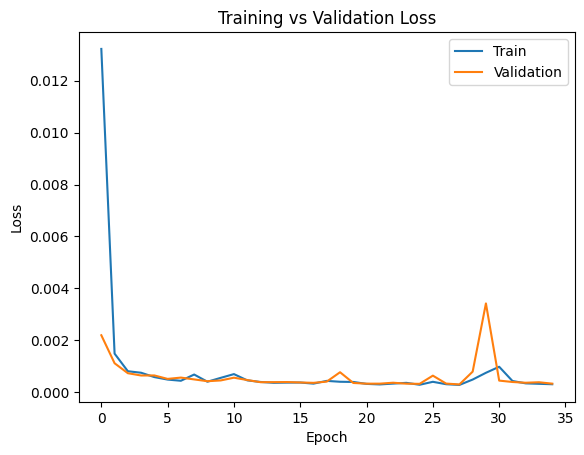

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


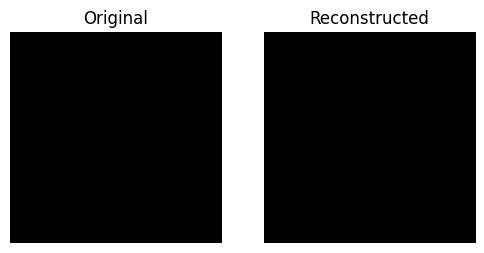

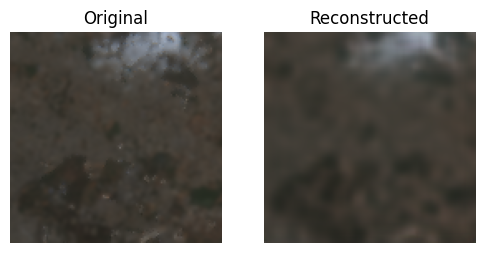

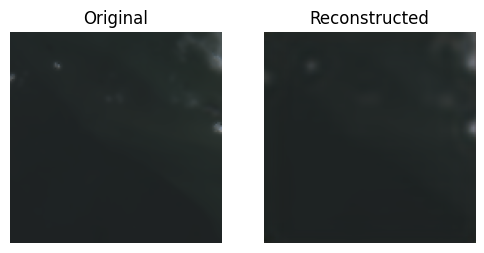

In [17]:
pred=autoencoder.predict(test_patches[:3])

for i in range(3):

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(test_patches[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred[i])
    plt.title("Reconstructed")
    plt.axis("off")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step


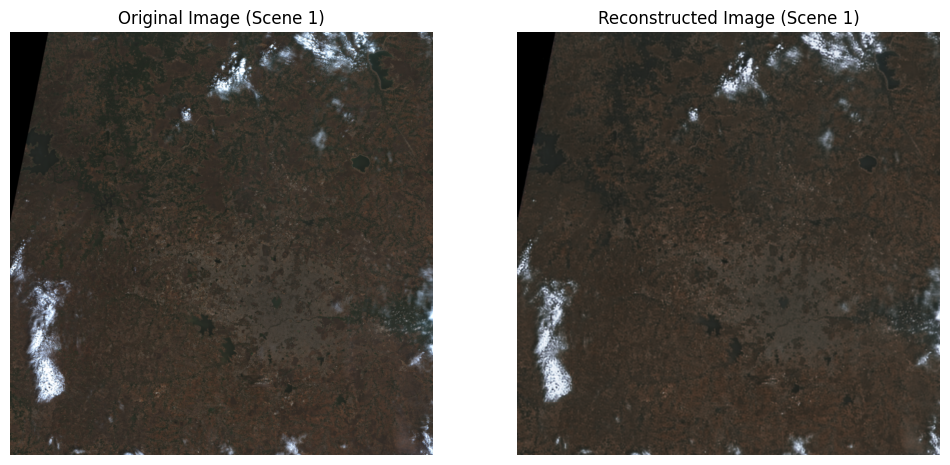

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step


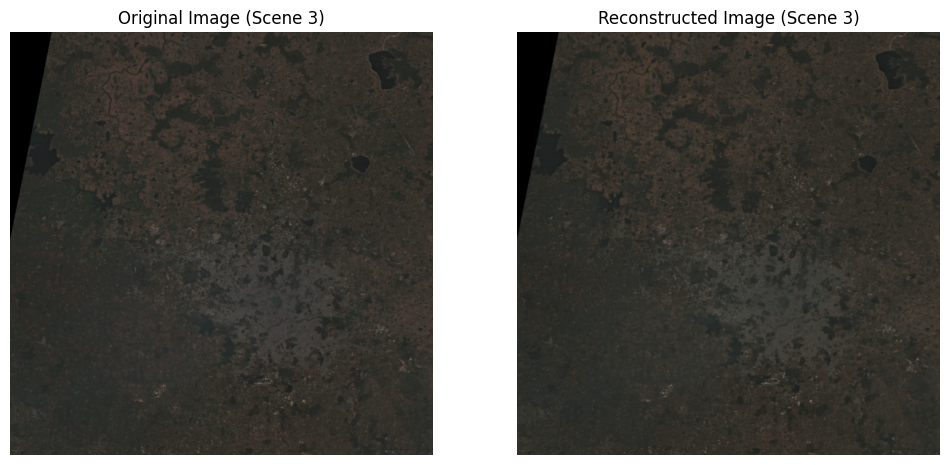

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 583ms/step


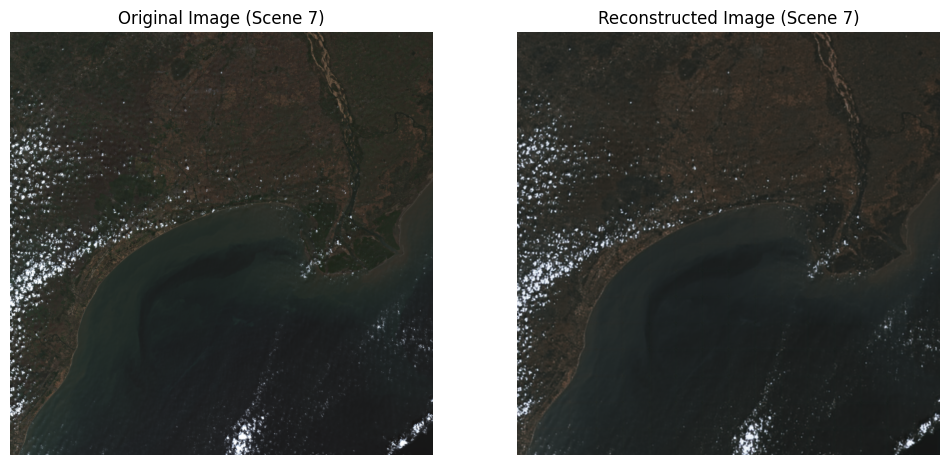

In [18]:
# Show reconstruction for multiple scenes

test_indices = [1, 3, 7]

for idx_scene in test_indices:

    test_img = load_scene(*scene_list[idx_scene])

    # Semantic preprocessing
    gray = cv2.cvtColor((test_img*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    mask = edges > np.mean(edges)
    blur = cv2.GaussianBlur(test_img, (5,5), 0)

    semantic = test_img.copy()
    mask3 = np.stack([mask]*3, axis=-1)
    semantic[~mask3] = blur[~mask3]

    # Extract patches
    patches = extract_patches(semantic)

    # Predict reconstruction
    pred = autoencoder.predict(patches)

    h, w, _ = semantic.shape
    patch_size = 128

    h_new = (h // patch_size) * patch_size
    w_new = (w // patch_size) * patch_size

    semantic_crop = semantic[:h_new, :w_new]

    reconstructed = np.zeros_like(semantic_crop)

    patch_id = 0

    for i in range(0, h_new, patch_size):
        for j in range(0, w_new, patch_size):

            reconstructed[i:i+patch_size, j:j+patch_size] = pred[patch_id]
            patch_id += 1

    # Display result
    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(semantic_crop)
    plt.title(f"Original Image (Scene {idx_scene})")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(reconstructed)
    plt.title(f"Reconstructed Image (Scene {idx_scene})")
    plt.axis("off")

    plt.show()

In [19]:
print("Original image shape:", semantic_crop.shape)
print("Reconstructed image shape:", reconstructed.shape)

Original image shape: (2048, 2048, 3)
Reconstructed image shape: (2048, 2048, 3)


In [20]:
pred=autoencoder.predict(test_patches)

psnr=[]
ssim=[]

for i in range(len(test_patches)):

    p=peak_signal_noise_ratio(test_patches[i],pred[i],data_range=1)

    s=structural_similarity(
        test_patches[i],
        pred[i],
        channel_axis=-1,
        data_range=1
    )

    psnr.append(p)
    ssim.append(s)

print("Average PSNR:",np.mean(psnr))
print("Average SSIM:",np.mean(ssim))

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 521ms/step
Average PSNR: 38.72573952492136
Average SSIM: 0.9248883


In [21]:
encoder=models.Model(autoencoder.input,encoded)

latent=encoder.predict(test_patches)

original_size=np.prod(test_patches[0].shape)
compressed_size=np.prod(latent[0].shape)

cr=original_size/compressed_size

print("Compression Ratio:",cr)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step
Compression Ratio: 6.0


In [22]:
print("Original patch shape:", test_patches[0].shape)

print("Encoded representation shape:", latent[0].shape)

original_size = np.prod(test_patches[0].shape)
compressed_size = np.prod(latent[0].shape)

print("Original size:", original_size)
print("Compressed size:", compressed_size)
print("Compression ratio:", original_size/compressed_size)

Original patch shape: (128, 128, 3)
Encoded representation shape: (16, 16, 32)
Original size: 49152
Compressed size: 8192
Compression ratio: 6.0


In [24]:
autoencoder.save("model.keras")

In [25]:
from google.colab import files
files.download("model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>